# **LESSON 3: VEHICLE ROUTING PROBLEM (VRP)**
By Diego Fiz

________________________________________________________________________________________________________________________________

## **Optimal Distribution Routes for Pastelerías Mallorca (Madrid)**

---

### **1. PROBLEM DESCRIPTION**

The solved problem is a variant of the **Vehicle Routing Problem (VRP)**, specifically modeled as a **Traveling Salesman Problem (TSP)** with additional constraints. A pastry distribution company must design the optimal route for a single vehicle starting from a central depot and visiting 5 stores at different locations in Madrid, minimizing the total weighted distance by considering location-specific traffic congestion factors.

#### **Problem features:**
- 1 central depot (node 0): Calle de la Barca 8, Madrid
- 5 client stores (nodes 1-5) located in different areas of Madrid
- **Objective:** Minimize the total weighted distance, considering traffic congestion
- **Constraint:** Each store must be visited exactly once
- The vehicle must start and finish at the depot
- Each destination has a unique congestion factor ($\alpha_j$) that weights the distances

---

### **2. MATHEMATICAL FORMULATION**

#### **2.1 Sets and Parameters**

**Sets:**
- $V = \{0, 1, 2, 3, 4, 5\}$: set of nodes, where 0 is the depot
- $n = 5$: number of customers (excluding the depot)

**Parameters:**
- $D_{\text{base}}[i,j]$: base distance matrix in kilometers, computed with the Haversine formula
- $\alpha_j$: congestion factor for destination $j$, where:
  - $\alpha_0 = 1.000$ (depot, no congestion)
  - $\alpha_1 = 1.625$ (central area)
  - $\alpha_2 = 2.028$ (commercial area)
  - $\alpha_3 = 4.570$ (high congestion in northern area)
  - $\alpha_4 = 4.428$ (heavy traffic area)
  - $\alpha_5 = 4.371$ (eastern area with congestion)

- Weighted distance matrix:
$$D[i,j] = D_{\text{base}}[i,j] \times \alpha_j$$

---

#### **2.2 Distance Calculation (Haversine Formula)**

The geodesic distance between two points is calculated by the Haversine formula:

$$a = \sin^2\left(\frac{\Delta \text{lat}}{2}\right) + \cos(\text{lat}_1) \cdot \cos(\text{lat}_2) \cdot \sin^2\left(\frac{\Delta \text{lon}}{2}\right)$$

$$d = 2R \cdot \arcsin(\sqrt{a})$$

where $R = 6371.0088$ km is Earth's mean radius.

---

#### **2.3 Decision Variables**

- $x_{ij} \in \{0,1\}$: binary variable equals 1 if the route goes directly from node $i$ to $j$, 0 otherwise
- $u_i \in \{1, 2, \ldots, n\}$: integer variable representing the position of node $i$ in the route (nodes 1 to 5 only)

---

#### **2.4 Objective Function**

$$
\min Z = \sum_{i=0}^{5} \sum_{j=0}^{5} D[i,j] \cdot x_{ij}
$$

Minimize the total weighted distance considering congestion factors.

---

#### **2.5 Constraints**

**A) No self-loops:**

$$x_{ii} = 0, \quad \forall i \in V$$

---

**B) Each customer is visited exactly once:**

$$\sum_{j \in V} x_{ij} = 1, \quad \forall i \in \{1,2,3,4,5\}$$

$$\sum_{i \in V} x_{ij} = 1, \quad \forall j \in \{1,2,3,4,5\}$$

---

**C) Vehicle departs and returns to depot exactly once:**

$$\sum_{j=1}^{5} x_{0j} = 1 \quad \text{(departure from depot)}$$

$$\sum_{i=1}^{5} x_{i0} = 1 \quad \text{(return to depot)}$$

---

**D) Subtour elimination (Miller-Tucker-Zemlin - MTZ):**

$$u_i - u_j + n \cdot x_{ij} \leq n - 1, \quad \forall i,j \in \{1,2,3,4,5\}, \, i \neq j$$

This constraint is essential to prevent the formation of independent cycles that do not include the depot.

---

**E) Business logic constraint (optional):**

$$\sum_{j \in V} x_{2j} \leq \sum_{j \in V} x_{1j}$$

If store 2 (Velázquez) is visited, store 1 (Serrano) must be also visited.

---

### **3. SOLUTION METHOD**

#### **3.1 Integer Linear Programming (ILP)**

The problem is solved via **Integer Linear Programming (ILP)** using the **PuLP solver with CBC**. This method guarantees finding the global optimal solution, unlike heuristics, which only provide approximations.

**Model characteristics:**
- **41 variables** (36 binary $x_{ij}$ + 5 integer $u_i$)
- **39 constraints**
- **Complexity:** $O(n^2)$ variables and $O(n^2)$ MTZ constraints

---

#### **3.2 Miller-Tucker-Zemlin (MTZ) Algorithm**

The MTZ method is a technique for eliminating subtours in TSP/VRP problems. It assigns order numbers ($u_i$) to each visited node, ensuring:
- The order increases along the route
- No independent cycles can form
- It is more efficient than other formulations for small/medium problems

---

#### **3.3 Route Reconstruction**

Once the ILP model is solved, the optimal route is reconstructed by:
- Building a successors dictionary based on variables where $x_{ij}=1$
- Following the sequence from the depot to complete the circuit
- Validating that no subtours exist via iteration limits

---

### **4. SENSITIVITY ANALYSIS**

The code implements two types of sensitivity analysis:

#### **4.1 Global Traffic Variation**
It evaluates the impact of increased congestion:
- Base traffic (100%): **53.92 km**
- Traffic +10%: **59.31 km**
- Traffic +25%: **67.40 km**
- Traffic +50%: **80.88 km**

#### **4.2 Temporary Store Closures**
It analyzes how the optimal route changes if some store cannot be visited, measuring the robustness of the distribution system to operational disruptions.

---

### **5. HEURISTIC COMPARISON**

To validate solution quality, a combined heuristic is implemented:

- **Nearest Neighbor (NN):** builds an initial solution by always visiting the nearest customer
- **2-opt:** a local improvement that swaps pairs of edges to reduce total distance

The **gap** between the heuristic and ILP optimum is **0.00%**, showing both methods found the same solution for this particular case.

---

### **6. OPTIMAL SOLUTION OBTAINED**

**Optimal route:** $0 \rightarrow 1 \rightarrow 2 \rightarrow 4 \rightarrow 3 \rightarrow 5 \rightarrow 0$

**Total weighted distance:** **53.92 km**

**Visit sequence:**
1. Depot (Calle de la Barca 8) - 0.0 km
2. Store 2 (Serrano 6) - 2.64 km
3. Store 3 (Velázquez 59) - 2.72 km
4. Store 5 (Aviador Zorita 39) - 10.64 km
5. Store 4 (Alberto Alcocer 48) - 8.68 km
6. Store 6 (Av. de los Andes 42) - 23.26 km
7. Return to Depot - 5.97 km

---

### **7. RESULT VISUALIZATION**

The code generates two visualizations:
1. **Route map:** shows the visit sequence geographically, with node size proportional to each congestion factor
2. **Sensitivity chart:** illustrates the impact of traffic increases on total distance

---

### **8. CONCLUSION**

This problem combines:
- **Combinatorial optimization**
- **Integer linear programming**
- **Geospatial analysis**
- **Sensitivity analysis**

All together, it provides a robust and practical solution to a real urban logistics problem with traffic variability by location.

---


![image.png](attachment:image.png)

## Solution:

MATRICES DE DISTANCIAS

Matriz D_base (distancias Haversine en km):
       0      1      2      3      4      5
0  0.000  1.625  2.028  4.570  4.428  5.974
1  1.625  0.000  1.339  4.238  3.442  7.069
2  2.028  1.339  0.000  2.908  2.404  6.161
3  4.570  4.238  2.908  0.000  1.900  5.322
4  4.428  3.442  2.404  1.900  0.000  6.999
5  5.974  7.069  6.161  5.322  6.999  0.000

Factores de congestión (alpha_j) por destino:
  Nodo 0: 1.000 - TIENDA 1 (DEPÓSITO): Calle de la Barca 8, Madrid
  Nodo 1: 1.625 - TIENDA 2: Calle Serrano 6, 28001 Madrid
  Nodo 2: 2.028 - TIENDA 3: Calle Velázquez 59, 28001 Madrid
  Nodo 3: 4.570 - TIENDA 4: Av. Alberto Alcocer 48, 28016 Madrid
  Nodo 4: 4.428 - TIENDA 5: Calle del Aviador Zorita 39, 28020 Madrid
  Nodo 5: 4.371 - TIENDA 6: Avenida de los Andes 42, 28042 Madrid

Matriz D (distancias ponderadas en km):
       0       1       2       3       4       5
0  0.000   2.641   4.113  20.886  19.609  26.113
1  1.625   0.000   2.716  19.369  15.239  30.898
2 

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


   Cierre de Nodo 4 (TIENDA 5: Calle del Aviador Zorita 39, 28020 Madrid): 47.88 km
   Cierre de Nodo 5 (TIENDA 6: Avenida de los Andes 42, 28042 Madrid): 29.25 km

COMPARACIÓN CON HEURÍSTICA

Heurística NN + 2-opt:
  Ruta: [0, 1, 2, 4, 3, 5, 0]
  Distancia: 53.92 km

Óptimo ILP: 53.92 km
Gap heurística: 0.00%


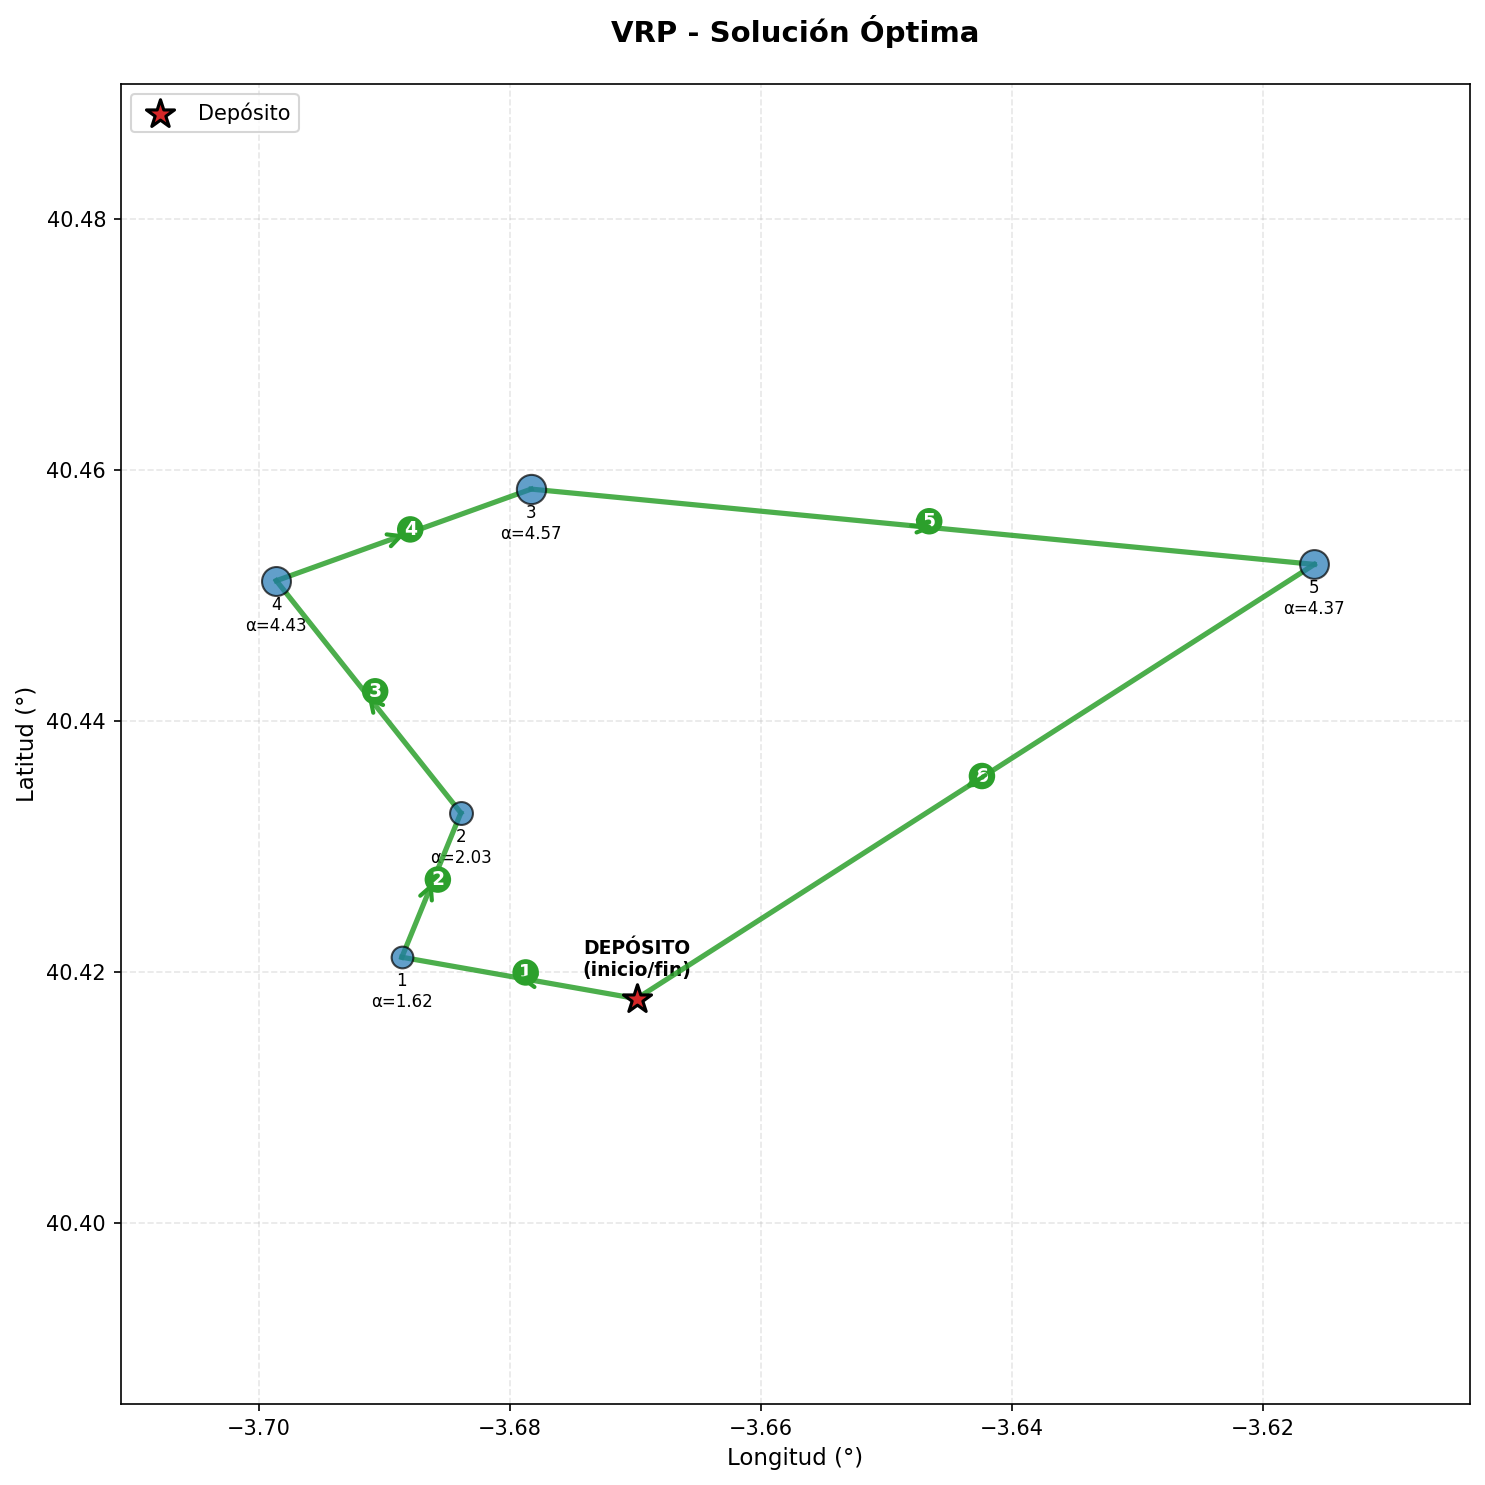

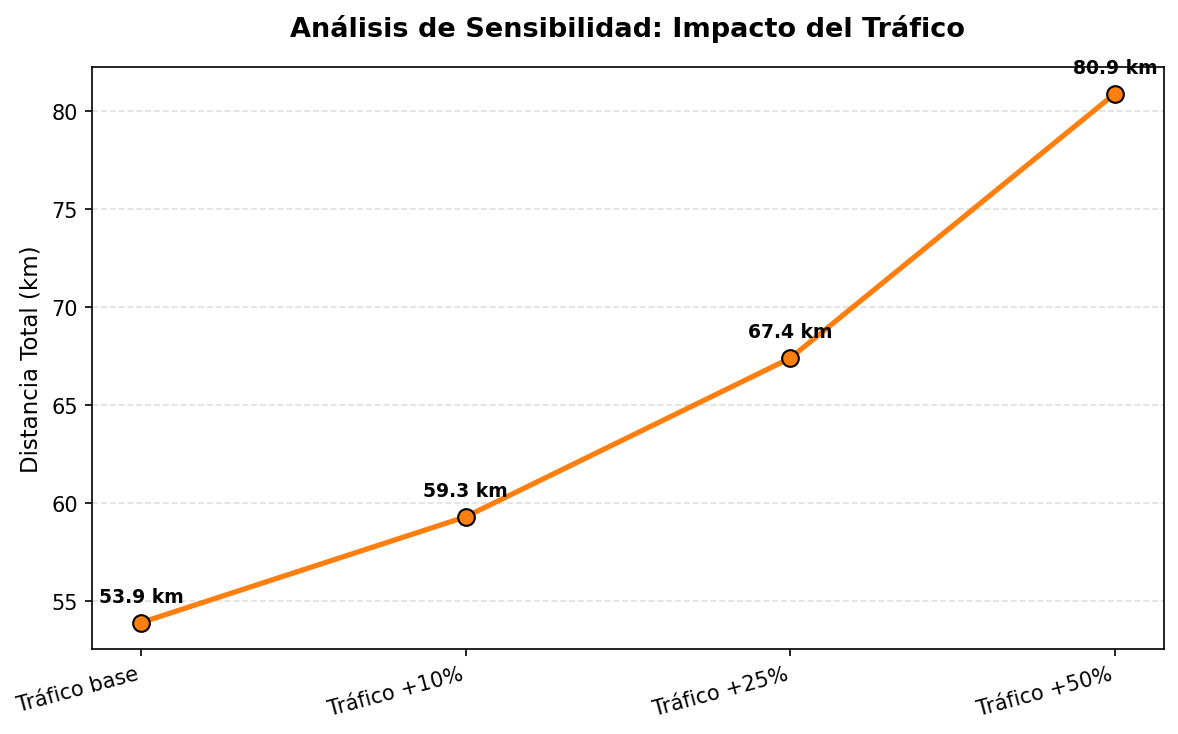

In [ ]:
# ============================================================
# VRP (Vehicle Routing Problem) - CÓDIGO FUSIONADO Y MEJORADO
# Caso: Pastelerías Mallorca (Madrid)
# ============================================================

import math
from itertools import product
import pulp as pl
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# ============================================================
# 1) DATOS DEL PROBLEMA
# ============================================================

# Direcciones de las tiendas (nodo 0 = depósito/obrador central)
addresses = {
    0: "TIENDA 1 (DEPÓSITO): Calle de la Barca 8, Madrid",
    1: "TIENDA 2: Calle Serrano 6, 28001 Madrid",
    2: "TIENDA 3: Calle Velázquez 59, 28001 Madrid",
    3: "TIENDA 4: Av. Alberto Alcocer 48, 28016 Madrid",
    4: "TIENDA 5: Calle del Aviador Zorita 39, 28020 Madrid",
    5: "TIENDA 6: Avenida de los Andes 42, 28042 Madrid",
}

# Coordenadas geográficas (latitud, longitud)
coords = {
    0: (40.4179, -3.6699),  # Obrador central
    1: (40.4212, -3.6886),  # Serrano 6
    2: (40.4327, -3.6839),  # Velázquez 59
    3: (40.4585, -3.6783),  # Alberto Alcocer 48
    4: (40.4512, -3.6986),  # Aviador Zorita 39
    5: (40.4525, -3.6159),  # Av. de los Andes 42
}

# Factores de congestión por destino (alpha_j)
# Representa el nivel de tráfico/dificultad para llegar a cada tienda
alpha_columns = {
    0: 1.000,    # Depósito (sin congestión adicional)
    1: 1.625,    # Serrano (zona centro con tráfico moderado)
    2: 2.028,    # Velázquez (zona comercial con alto tráfico)
    3: 4.570,    # Alberto Alcocer (zona norte, muy congestionada)
    4: 4.428,    # Aviador Zorita (zona con mucho tráfico)
    5: 4.371,    # Av. de los Andes (zona este con congestión)
}

# ============================================================
# 2) CÁLCULO DE DISTANCIAS
# ============================================================

def haversine_km(p, q):
    """
    Calcula la distancia geodésica entre dos puntos en km
    usando la fórmula de Haversine

    Parámetros:
        p, q: tuplas (latitud, longitud) en grados

    Retorna:
        distancia en kilómetros
    """
    R = 6371.0088  # Radio medio de la Tierra en km
    lat1, lon1 = math.radians(p[0]), math.radians(p[1])
    lat2, lon2 = math.radians(q[0]), math.radians(q[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return 2 * R * math.asin(math.sqrt(a))

nodes = sorted(addresses.keys())
n = len(nodes) - 1  # número de clientes (excluyendo depósito)

# Matriz de distancias base (sin factores de congestión)
D_base = {(i, j): (0.0 if i == j else haversine_km(coords[i], coords[j]))
          for i, j in product(nodes, nodes)}

# Matriz de distancias ponderada (con factores de congestión por columna)
# D[i,j] = D_base[i,j] * alpha_columns[j]
D = {(i, j): D_base[i, j] * alpha_columns[j]
     for i, j in product(nodes, nodes)}

# ============================================================
# 3) IMPRIMIR MATRICES DE DISTANCIAS
# ============================================================

print("="*80)
print("MATRICES DE DISTANCIAS")
print("="*80)

# Matriz base
df_base = pd.DataFrame([[D_base[i,j] for j in nodes] for i in nodes],
                       index=nodes, columns=nodes)
print("\nMatriz D_base (distancias Haversine en km):")
print(df_base.round(3))

# Factores alpha
print("\nFactores de congestión (alpha_j) por destino:")
for j in nodes:
    print(f"  Nodo {j}: {alpha_columns[j]:.3f} - {addresses[j]}")

# Matriz ponderada
df_weighted = pd.DataFrame([[D[i,j] for j in nodes] for i in nodes],
                           index=nodes, columns=nodes)
print("\nMatriz D (distancias ponderadas en km):")
print(df_weighted.round(3))

# ============================================================
# 4) MODELO DE OPTIMIZACIÓN (ILP con MTZ)
# ============================================================

print("\n" + "="*80)
print("MODELO DE PROGRAMACIÓN LINEAL ENTERA")
print("="*80)

model = pl.LpProblem("VRP_TSP_MTZ_Optimizado", pl.LpMinimize)

# Variables de decisión binarias: x[i][j] = 1 si la ruta va de i a j
x = pl.LpVariable.dicts("x", (nodes, nodes), lowBound=0, upBound=1, cat=pl.LpBinary)

# Variables de orden MTZ para eliminación de subciclos
u = {i: pl.LpVariable(f"u_{i}", lowBound=1, upBound=n, cat=pl.LpInteger)
     for i in nodes if i != 0}

# Función objetivo: minimizar distancia total ponderada
model += pl.lpSum(D[i, j] * x[i][j] for i, j in product(nodes, nodes)), "TotalDistance"

# Restricción A: Prohibir auto-bucles (no ir de un nodo a sí mismo)
for i in nodes:
    model += x[i][i] == 0, f"NoSelfLoop_{i}"

# Restricción B: Cada cliente se visita exactamente una vez
for i in range(1, n + 1):
    model += pl.lpSum(x[i][j] for j in nodes) == 1, f"LeaveNode_{i}"
for j in range(1, n + 1):
    model += pl.lpSum(x[i][j] for i in nodes) == 1, f"EnterNode_{j}"

# Restricción C: El vehículo sale y regresa al depósito exactamente una vez
model += pl.lpSum(x[0][j] for j in range(1, n + 1)) == 1, "LeaveDepot"
model += pl.lpSum(x[i][0] for i in range(1, n + 1)) == 1, "ReturnDepot"

# Restricción D: Eliminación de subciclos (Miller-Tucker-Zemlin)
for i in range(1, n + 1):
    for j in range(1, n + 1):
        if i != j:
            model += u[i] - u[j] + n * x[i][j] <= n - 1, f"MTZ_{i}_{j}"

# Restricción E (opcional/lógica):
# Si se visita Velázquez(2), también debe visitarse Serrano(1)
# (ejemplo de restricción de negocio)
model += pl.lpSum(x[2][j] for j in nodes) <= pl.lpSum(x[1][j] for j in nodes), "BusinessRule_Velazquez"

print("\nModelo construido:")
print(f"  - Variables: {len(model.variables())}")
print(f"  - Restricciones: {len(model.constraints)}")

# ============================================================
# 5) RESOLVER EL MODELO
# ============================================================

print("\nResolviendo el modelo...")
status = model.solve(pl.PULP_CBC_CMD(msg=False))

if pl.LpStatus[status] != "Optimal":
    raise RuntimeError(f"Modelo no encontró solución óptima: {pl.LpStatus[status]}")

print(f"Estado: {pl.LpStatus[status]}")
print(f"Valor objetivo: {pl.value(model.objective):.2f} km")

# ============================================================
# 6) RECONSTRUIR Y VALIDAR LA RUTA
# ============================================================

# Construir diccionario de sucesores
succ = {}
for i in nodes:
    for j in nodes:
        if i != j and x[i][j].varValue and x[i][j].varValue > 0.5:
            succ[i] = j

# Reconstruir ruta comenzando desde el depósito
route = [0]
limit = 2 * len(nodes) + 5
while route[-1] != 0 or len(route) == 1:
    cur = route[-1]
    if cur not in succ:
        raise RuntimeError(f"Sin sucesor para nodo {cur}. Revisa el modelo.")
    nxt = succ[cur]
    route.append(nxt)
    if len(route) > limit:
        raise RuntimeError("Reconstrucción excede límite. Posible subciclo.")

# Calcular distancia total
total_km = sum(D[(route[k], route[k+1])] for k in range(len(route) - 1))

# ============================================================
# 7) MOSTRAR RESULTADOS
# ============================================================

print("\n" + "="*80)
print("SOLUCIÓN ÓPTIMA")
print("="*80)

print("\nRuta óptima (secuencia de nodos):")
print(" -> ".join(map(str, route)))

print("\nRuta óptima (direcciones completas):")
for idx, node in enumerate(route):
    prefix = f"  {idx}. " if idx > 0 else "  INICIO: "
    print(f"{prefix}{addresses[node]}")

print(f"\nDistancia total ponderada: {total_km:.2f} km")

# Detalle de cada tramo
print("\nDetalle de tramos:")
df_route = pd.DataFrame({
    "Desde": [addresses[route[k]] for k in range(len(route)-1)],
    "Hasta": [addresses[route[k+1]] for k in range(len(route)-1)],
    "Dist. Base (km)": [D_base[(route[k], route[k+1])] for k in range(len(route)-1)],
    "Factor Alpha": [alpha_columns[route[k+1]] for k in range(len(route)-1)],
    "Dist. Ponderada (km)": [D[(route[k], route[k+1])] for k in range(len(route)-1)]
})
print(df_route.to_string(index=False))

# ============================================================
# 8) ANÁLISIS DE SENSIBILIDAD
# ============================================================

def solve_with_alpha_dict(alpha_dict, close_node=None):
    """
    Resuelve el VRP con diferentes factores de congestión y/o nodos cerrados

    Parámetros:
        alpha_dict: diccionario {j: alpha_j} de factores por destino
        close_node: nodo a excluir de la ruta (None = ninguno)

    Retorna:
        Valor objetivo (distancia total) o None si no hay solución
    """
    D2 = {(i, j): D_base[i, j] * alpha_dict.get(j, 1.0)
          for i, j in product(nodes, nodes)}

    banned = set([close_node]) if (close_node is not None and close_node != 0) else set()

    mdl = pl.LpProblem("VRP_Sensitivity", pl.LpMinimize)
    x2 = pl.LpVariable.dicts("x", (nodes, nodes), 0, 1, pl.LpBinary)
    u2 = {i: pl.LpVariable(f"u_{i}", 1, n, pl.LpInteger) for i in nodes if i != 0}

    mdl += pl.lpSum(D2[i, j] * x2[i][j] for i, j in product(nodes, nodes)), "Z"

    for i in nodes:
        mdl += x2[i][i] == 0

    for i in range(1, n + 1):
        if i in banned:
            mdl += pl.lpSum(x2[i][j] for j in nodes) == 0
        else:
            mdl += pl.lpSum(x2[i][j] for j in nodes) == 1

    for j in range(1, n + 1):
        if j in banned:
            mdl += pl.lpSum(x2[i][j] for i in nodes) == 0
        else:
            mdl += pl.lpSum(x2[i][j] for i in nodes) == 1

    if banned:
        mdl += pl.lpSum(x2[0][j] for j in range(1, n + 1) if j not in banned) == 1
        mdl += pl.lpSum(x2[i][0] for i in range(1, n + 1) if i not in banned) == 1
    else:
        mdl += pl.lpSum(x2[0][j] for j in range(1, n + 1)) == 1
        mdl += pl.lpSum(x2[i][0] for i in range(1, n + 1)) == 1

    for i in range(1, n + 1):
        for j in range(1, n + 1):
            if i != j and i not in banned and j not in banned:
                mdl += u2[i] - u2[j] + n * x2[i][j] <= n - 1

    st = mdl.solve(pl.PULP_CBC_CMD(msg=False))
    if pl.LpStatus[st] != "Optimal":
        return None
    return pl.value(mdl.objective)

print("\n" + "="*80)
print("ANÁLISIS DE SENSIBILIDAD")
print("="*80)

# Escenario 1: Variaciones en el tráfico global
print("\n1. Efecto de incremento global del tráfico:")
traffic_scenarios = [
    ("Tráfico base", {j: alpha_columns[j] * 1.00 for j in nodes}),
    ("Tráfico +10%", {j: alpha_columns[j] * 1.10 for j in nodes}),
    ("Tráfico +25%", {j: alpha_columns[j] * 1.25 for j in nodes}),
    ("Tráfico +50%", {j: alpha_columns[j] * 1.50 for j in nodes}),
]

sens_results = []
for desc, alpha_dict in traffic_scenarios:
    result = solve_with_alpha_dict(alpha_dict)
    sens_results.append({"Escenario": desc, "Distancia (km)": result})
    print(f"   {desc}: {result:.2f} km")

df_sens = pd.DataFrame(sens_results)

# Escenario 2: Cierre temporal de tiendas
print("\n2. Efecto del cierre temporal de tiendas:")
for node in range(1, len(nodes)):
    result = solve_with_alpha_dict(alpha_columns, close_node=node)
    status_msg = f"{result:.2f} km" if result else "No factible"
    print(f"   Cierre de Nodo {node} ({addresses[node]}): {status_msg}")

# ============================================================
# 9) HEURÍSTICA COMPARATIVA (NEAREST NEIGHBOR + 2-OPT)
# ============================================================

def route_length(rt, D):
    """Calcula la longitud total de una ruta"""
    return sum(D[(rt[k], rt[k+1])] for k in range(len(rt)-1))

def nearest_neighbor(order, D):
    """Heurística del vecino más cercano"""
    unv = set(order[1:])
    rt = [order[0]]
    cur = order[0]
    while unv:
        nxt = min(unv, key=lambda j: D[(cur, j)])
        rt.append(nxt)
        unv.remove(nxt)
        cur = nxt
    rt.append(order[0])
    return rt

def two_opt(route, D):
    """Mejora local con intercambios 2-opt"""
    best = route[:]
    best_len = route_length(best, D)
    improved = True
    while improved:
        improved = False
        for i in range(1, len(best)-2):
            for j in range(i+1, len(best)-1):
                if j - i == 1:
                    continue
                new = best[:i] + best[i:j][::-1] + best[j:]
                new_len = route_length(new, D)
                if new_len + 1e-9 < best_len:
                    best, best_len = new, new_len
                    improved = True
    return best, best_len

print("\n" + "="*80)
print("COMPARACIÓN CON HEURÍSTICA")
print("="*80)

nn_route = nearest_neighbor(nodes, D)
nn2_route, nn2_len = two_opt(nn_route, D)

print(f"\nHeurística NN + 2-opt:")
print(f"  Ruta: {nn2_route}")
print(f"  Distancia: {nn2_len:.2f} km")
print(f"\nÓptimo ILP: {total_km:.2f} km")
print(f"Gap heurística: {((nn2_len - total_km) / total_km * 100):.2f}%")

# ============================================================
# 10) VISUALIZACIÓN
# ============================================================

def plot_route_map(coords, addresses, route, alpha_columns,
                   title="VRP - Solución Óptima", filename="vrp_map.png"):
    """Genera un mapa visual de la ruta"""
    depot = 0
    clients = [i for i in coords.keys() if i != depot]

    lons = {i: coords[i][1] for i in coords}
    lats = {i: coords[i][0] for i in coords}

    fig, ax = plt.subplots(figsize=(10, 10), dpi=150)

    # Ajustar límites con margen
    all_x = list(lons.values())
    all_y = list(lats.values())
    pad_x = (max(all_x) - min(all_x)) * 0.15
    pad_y = (max(all_y) - min(all_y)) * 0.15
    ax.set_xlim(min(all_x) - pad_x, max(all_x) + pad_x)
    ax.set_ylim(min(all_y) - pad_y, max(all_y) + pad_y)

    # Dibujar depósito
    ax.scatter(lons[depot], lats[depot], c="#d62728", s=200, marker="*",
               zorder=5, label="Depósito", edgecolors="black", linewidths=1.5)
    ax.text(lons[depot], lats[depot]+0.0015, "DEPÓSITO\n(inicio/fin)",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

    # Dibujar clientes con tamaño proporcional al factor alpha
    for i in clients:
        size = 60 + alpha_columns[i] * 30
        ax.scatter(lons[i], lats[i], c="#1f77b4", s=size, marker="o",
                   zorder=4, alpha=0.7, edgecolors="black", linewidths=1)
        ax.text(lons[i], lats[i]-0.0012, f"{i}\nα={alpha_columns[i]:.2f}",
                ha="center", va="top", fontsize=8)

    # Dibujar ruta con flechas
    for k in range(len(route) - 1):
        i, j = route[k], route[k+1]
        x1, y1 = lons[i], lats[i]
        x2, y2 = lons[j], lats[j]

        # Línea del tramo
        ax.plot([x1, x2], [y1, y2], c="#2ca02c", lw=2.5, alpha=0.85, zorder=3)

        # Flecha direccional
        midx, midy = (x1 + x2) / 2, (y1 + y2) / 2
        dx, dy = x2 - x1, y2 - y1
        arr = FancyArrowPatch(
            (midx - dx*0.02, midy - dy*0.02),
            (midx + dx*0.02, midy + dy*0.02),
            arrowstyle="->", mutation_scale=15, color="#2ca02c", lw=2, zorder=6)
        ax.add_patch(arr)

        # Número de orden
        ax.text(midx, midy, f"{k+1}", fontsize=9, color="white",
                fontweight="bold",
                bbox=dict(boxstyle="circle,pad=0.2", fc="#2ca02c", ec="none"))

    ax.set_title(title, fontsize=14, fontweight="bold", pad=20)
    ax.set_xlabel("Longitud (°)", fontsize=11)
    ax.set_ylabel("Latitud (°)", fontsize=11)
    ax.legend(loc="upper left", fontsize=10)
    ax.grid(ls="--", alpha=0.3)
    ax.set_aspect("equal", adjustable="datalim")

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight", dpi=150)
    plt.show()

def plot_sensitivity(sens_df, filename="vrp_sensitivity.png"):
    """Genera gráfico de análisis de sensibilidad"""
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

    x = range(len(sens_df))
    y = sens_df["Distancia (km)"]

    ax.plot(x, y, "o-", color="#ff7f0e", lw=2.5, ms=8, markeredgecolor="black")

    for i, (escenario, dist) in enumerate(zip(sens_df["Escenario"], y)):
        ax.annotate(f"{dist:.1f} km", (i, dist),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=9, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(sens_df["Escenario"], rotation=15, ha="right")
    ax.set_title("Análisis de Sensibilidad: Impacto del Tráfico",
                 fontsize=13, fontweight="bold", pad=15)
    ax.set_ylabel("Distancia Total (km)", fontsize=11)
    ax.grid(ls="--", alpha=0.4, axis="y")

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight", dpi=150)
    plt.show()

# Generar visualizaciones
plot_route_map(coords, addresses, route, alpha_columns)
plot_sensitivity(df_sens)